# Taller Final — NLP con Transformers
## RAG aplicado a Conceptos de Ingeniería de Petróleos

**Integrantes:** Maria Camila Peñaloza — Miguel Casteblanco — Anthony D'Croz

**Fecha:** Mayo 2026

---

## 1. Definición del Problema

### 1.1 Resumen del pipeline

Este proyecto implementa un sistema **RAG (Retrieval-Augmented Generation)** que responde preguntas técnicas sobre ingeniería de petróleos. El pipeline funciona así:

1. **Corpus**: 12 documentos de fuentes públicas (EIA, USGS, SLB Glossary) sobre temas como petróleo crudo, refinación, permeabilidad, gas natural, sistemas petroleros y fluidos de perforación.
2. **Retrieval**: se embeben los chunks del corpus con `sentence-transformers` y se indexan con FAISS. Ante una pregunta del usuario, se recuperan los `k` chunks más similares.
3. **Generation**: los chunks recuperados se pasan como contexto a un modelo de lenguaje (Flan-T5) que genera la respuesta final.

### 1.2 ¿Por qué es útil?

Estudiantes de ingeniería de petróleos frecuentemente necesitan consultar definiciones y conceptos técnicos dispersos en manuales, reportes de la EIA, el glosario de SLB y publicaciones del USGS. Este sistema centraliza ese conocimiento y permite hacer consultas en lenguaje natural, sin tener que buscar manualmente en múltiples fuentes. Beneficia a:

- Estudiantes universitarios de ingeniería de petróleos.
- Ingenieros junior que necesitan referencia rápida.
- Docentes que quieren herramientas de apoyo pedagógico.

### 1.3 Tipo de tarea NLP

**RAG** (Retrieval-Augmented Generation).

### 1.4 Datos

Corpus construido a partir de fuentes públicas / educativas:
- **EIA** (U.S. Energy Information Administration) — información pública del gobierno de EE.UU.
- **USGS** (U.S. Geological Survey) — publicaciones de dominio público.
- **SLB Energy Glossary** — glosario de términos técnicos (uso educativo con atribución).

Total: 12 documentos, 116 chunks, 33,304 palabras.

### 1.5 Métrica principal de éxito

**Recall@k**: proporción de preguntas de prueba para las cuales al menos uno de los top-k chunks recuperados contiene las palabras clave de la respuesta esperada. Complementado con evaluación cualitativa de la coherencia de las respuestas generadas.

### 1.6 ¿Por qué RAG y no otra tarea?

Un sistema de **QA extractivo** (p. ej. BERT-QA) requiere que la respuesta esté dentro de un único contexto predefinido. Aquí el conocimiento está repartido en 12 documentos y 116 chunks — el sistema necesita primero *encontrar* el fragmento correcto antes de responder. Eso es exactamente lo que hace RAG.

Una **clasificación** no resuelve el problema porque el usuario quiere una respuesta, no una categoría. Un **NER** tampoco aplica porque no estamos extrayendo entidades sino respondiendo preguntas conceptuales.

---

## 2. Datos y Preprocesamiento

In [37]:
# ── Instalación de dependencias
INSTALL = False # True
if INSTALL:
    !pip install -e

In [38]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
#from google.colab import files
import io


In [39]:
CORPUS_DIR = Path("data/petroleum_corpus/clean")

docs   = pd.read_json(CORPUS_DIR / "documents.jsonl", lines=True)
chunks = pd.read_json(CORPUS_DIR / "chunks.jsonl",    lines=True)

print(f"Cargado correctamente")
print(f"Documentos: {len(docs)}")
print(f"Chunks    : {len(chunks)}")
print(f"Palabras totales: {docs['word_count'].sum():,}")

Cargado correctamente
Documentos: 12
Chunks    : 116
Palabras totales: 33,304


### 2.1 Tabla de estadísticas del corpus

In [40]:
# Tabla resumen del corpus
stats = pd.DataFrame({
    "Métrica": [
        "Documentos",
        "Chunks",
        "Palabras totales",
        "Media palabras / documento",
        "Mediana palabras / chunk",
        "Media palabras / chunk",
        "Chunk más largo (palabras)",
        "Chunk más corto (palabras)",
    ],
    "Valor": [
        len(docs),
        len(chunks),
        f"{docs['word_count'].sum():,}",
        f"{docs['word_count'].mean():.1f}",
        f"{chunks['word_count'].median():.1f}",
        f"{chunks['word_count'].mean():.1f}",
        chunks['word_count'].max(),
        chunks['word_count'].min(),
    ]
})

display(stats)

# Tabla por documento
display(
    docs[["topic", "title", "word_count", "url"]]
    .rename(columns={"topic": "Tema", "title": "Título", "word_count": "Palabras", "url": "URL"})
    .style.set_caption("Documentos del corpus")
)

,Métrica,Valor
0,Documentos,12
1,Chunks,116
2,Palabras totales,"33,304"
3,Media palabras / documento,2775.3
4,Mediana palabras / chunk,350.0
5,Media palabras / chunk,334.5
6,Chunk más largo (palabras),350
7,Chunk más corto (palabras),75


,Tema,Título,Palabras,URL
0,oil_basics,Oil and petroleum products explained - U.S. Energy Information Administration (EIA),725,https://www.eia.gov/energyexplained/oil-and-petroleum-products/
1,oil_supply_and_production,Where our oil comes from in depth - U.S. Energy Information Administration (EIA),1173,https://www.eia.gov/energyexplained/oil-and-petroleum-products/where-our-oil-comes-from-in-depth.php
2,refining,Refining crude oil - the refining process - U.S. Energy Information Administration (EIA),910,https://www.eia.gov/energyexplained/oil-and-petroleum-products/refining-crude-oil-the-refining-process.php
3,natural_gas_basics,Natural gas explained - U.S. Energy Information Administration (EIA),1411,https://www.eia.gov/energyexplained/natural-gas/
4,petroleum_systems,"Petroleum Systems and Geologic Assessment of Oil and Gas in the San Joaquin Basin Province, California",1327,https://pubs.usgs.gov/pp/pp1713/
5,petroleum_systems_pdf,USGS Chapter PS: Petroleum Systems,25611,https://pubs.usgs.gov/of/1998/ofr-98-0034/PS.pdf
6,permeability,permeability | Energy Glossary,476,https://glossary.slb.com/en/terms/p/permeability
7,porosity,effective porosity | Energy Glossary,362,https://glossary.slb.com/en/terms/e/effective_porosity
8,pore_pressure,pore pressure | Energy Glossary,262,https://glossary.slb.com/en/terms/p/pore_pressure
9,well_logging,log | Energy Glossary,661,https://glossary.slb.com/en/terms/l/log


### 2.2 Análisis exploratorio visual

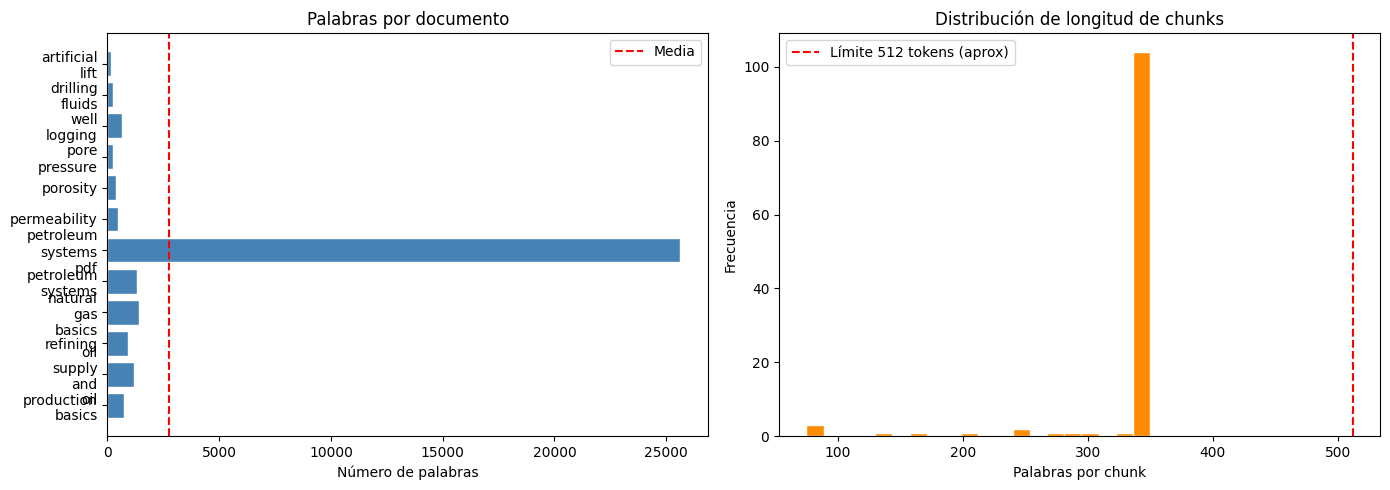


Nota: 0 chunks superan las ~400 palabras (pueden exceder 512 tokens).


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica 1: Palabras por documento (barras) ───────────────────────────────
topics_short = docs["topic"].str.replace("_", "\n")
axes[0].barh(topics_short, docs["word_count"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Número de palabras")
axes[0].set_title("Palabras por documento")
axes[0].axvline(docs["word_count"].mean(), color="red", linestyle="--", label="Media")
axes[0].legend()

# ── Gráfica 2: Distribución de longitudes de chunks ──────────────────────────
axes[1].hist(chunks["word_count"], bins=20, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Palabras por chunk")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de longitud de chunks")
axes[1].axvline(512, color="red", linestyle="--", label="Límite 512 tokens (aprox)")
axes[1].legend()

plt.tight_layout()
plt.savefig("./figures/corpus_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nNota: {(chunks['word_count'] > 400).sum()} chunks superan las ~400 palabras (pueden exceder 512 tokens).")

In [42]:
# ── Ejemplos de chunks por tema ───────────────────────────────────────────────
print("=== 3 ejemplos de chunks ===\n")
sample_topics = ["permeability", "refining", "natural_gas_basics"]
for topic in sample_topics:
    row = chunks[chunks["topic"] == topic].iloc[0]
    print(f"TEMA: {row['topic']}")
    print(f"FUENTE: {row['url']}")
    print(f"TEXTO (primeras 300 chars): {row['text'][:300]}...")
    print("-" * 70)

=== 3 ejemplos de chunks ===

TEMA: permeability
FUENTE: https://glossary.slb.com/en/terms/p/permeability
TEXTO (primeras 300 chars): Explore the Energy Glossary Look up terms beginning with: permeability The ability, or measurement of a rock 's ability, to transmit fluids, typically measured in darcies or millidarcies. The term was basically defined by Henry Darcy, who showed that the common mathematics of heat transfer could be ...
----------------------------------------------------------------------
TEMA: refining
FUENTE: https://www.eia.gov/energyexplained/oil-and-petroleum-products/refining-crude-oil-the-refining-process.php
TEXTO (primeras 300 chars): Oil and petroleum products explained Refining crude oil Also in What is energy? Also in Units and calculators explained Energy conversion calculators British thermal units (Btu) Also in U.S. energy facts explained Consumption and production State and U.S. territory data Also in Use of energy explain...
-----------------------------

## 3. Elección y Justificación del Modelo

### 3.1 Modelo elegido

| Campo | Detalle |
|---|---|
| **Modelo de embeddings** | `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` |
| **Tipo de arquitectura** | Encoder-only (MPNet) |
| **Pre-entrenado en** | Pares de oraciones en 50+ idiomas (incluye inglés y español) |
| **¿Requiere fine-tuning?** | No — produce embeddings de alta calidad para similitud semántica directamente |
| **Parámetros** | ~278 millones |
| **Modelo generador** | `google/flan-t5-base` (Encoder-Decoder, 250M parámetros, instruido para QA) |

### 3.2 ¿Por qué este modelo y no otro?

**Alternativa descartada 1 — `bert-base-uncased`:** BERT base no está optimizado para similitud semántica entre oraciones; produce embeddings de tokens, no de oraciones. Requeriría fine-tuning adicional con datos de similitud para funcionar como retriever.

**Alternativa descartada 2 — `text-embedding-ada-002` (OpenAI):** produce embeddings de excelente calidad pero requiere una API de pago y envío de datos a servidores externos, lo que limita la reproducibilidad del taller y podría ser un problema de privacidad en contextos reales.

**¿Por qué `paraphrase-multilingual-mpnet-base-v2`?**
- El corpus está en inglés pero el sistema podría recibir preguntas en español → el modelo multilingüe lo maneja sin problema.
- Está optimizado específicamente para similitud semántica de oraciones, que es exactamente lo que necesita el retriever.
- Es open-source, gratuito y funciona localmente en Colab.
- Tiene buen desempeño en dominios técnicos según los benchmarks de SBERT.

**¿Por qué `flan-t5-base` como generador?**
- Fue afinado con instrucciones (instruction-tuned), por lo que responde bien a prompts estilo "Answer the following question based on the context".
- Es suficientemente pequeño para correr en Colab sin GPU dedicada.
- Alternativa descartada: `gpt2` — no es un modelo de instrucciones; tiende a continuar texto en lugar de responder preguntas.

---

## 4. Implementación y Evaluación

### 4.1 Preguntas de prueba

In [43]:
# Preguntas de prueba con palabras clave de respuesta esperada
# (usamos keywords porque el corpus está en inglés pero las preguntas pueden venir en español)
with open("./data/sources/rag_test_questions.json") as f:
    preguntas_prueba = json.load(f)
    
print(f"Preguntas de prueba cargadas: {len(preguntas_prueba)}")
for i, p in enumerate(preguntas_prueba, 1):
    print(f"  {i}. {p['pregunta']}")

Preguntas de prueba cargadas: 11
  1. What is permeability in petroleum engineering?
  2. How is crude oil refined into petroleum products?
  3. What is pore pressure and why does it matter in drilling?
  4. What is natural gas and how is it used?
  5. What is gas lift in artificial lift systems?
  6. Que es la porosidad efectiva en una roca reservorio?
  7. Why are drilling fluids important during well construction?
  8. How does well logging help characterize a reservoir?
  9. What is the difference between conventional and unconventional oil resources?
  10. How does permeability affect production rates in a petroleum reservoir?
  11. What makes a petroleum system complete and ready for exploration?


### 4.2 Embeddings y construcción del índice FAISS

In [44]:
from sentence_transformers import SentenceTransformer
import faiss

# Cargar modelo de embeddings
print("Cargando modelo de embeddings...")
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# Embeber todos los chunks
print("Generando embeddings de los chunks...")
chunk_texts = chunks["text"].tolist()
chunk_embeddings = embed_model.encode(chunk_texts, show_progress_bar=True, batch_size=32)

# Normalizar para similitud coseno con IndexFlatIP
chunk_embeddings = chunk_embeddings / np.linalg.norm(chunk_embeddings, axis=1, keepdims=True)

print(f"Shape de embeddings: {chunk_embeddings.shape}")

Cargando modelo de embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6514.72it/s]


Generando embeddings de los chunks...


Batches: 100%|██████████| 4/4 [00:07<00:00,  1.83s/it]

Shape de embeddings: (116, 768)


In [45]:
# Construir índice FAISS (coseno via Inner Product con vectores normalizados)
dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings.astype(np.float32))

print(f"Índice FAISS construido con {index.ntotal} vectores de dimensión {dim}")

Índice FAISS construido con 116 vectores de dimensión 768


### 4.3 Función de recuperación (Retrieval)

In [46]:
def recuperar(pregunta: str, k: int = 3) -> pd.DataFrame:
    """
    Recupera los k chunks más relevantes para una pregunta.
    Retorna un DataFrame con chunk_id, topic, title, url, text y score.
    """
    q_emb = embed_model.encode([pregunta]).astype(np.float32)
    q_emb = q_emb / np.linalg.norm(q_emb)
    scores, indices = index.search(q_emb, k)

    resultados = chunks.iloc[indices[0]].copy().reset_index(drop=True)
    resultados["similitud"] = scores[0]  # coseno directo (-1 a 1)
    return resultados[["chunk_id", "topic", "title", "url", "text", "similitud"]]

# Prueba rápida
resultado_prueba = recuperar("What is permeability?")
print(resultado_prueba[["topic", "similitud"]].to_string())

          topic  similitud
0  permeability   0.679749
1      porosity   0.475650
2  permeability   0.460096


### 4.4 Diagnóstico de retrieval para las preguntas de prueba

In [47]:
K = 3  # número de chunks a recuperar

print(f"{'='*70}")
print(f"DIAGNÓSTICO DE RETRIEVAL (top-{K} chunks por pregunta)")
print(f"{'='*70}\n")

for i, p in enumerate(preguntas_prueba, 1):
    resultados = recuperar(p["pregunta"], k=K)
    print(f"[{i}] PREGUNTA: {p['pregunta']}")
    print(f"     TEMA ESPERADO: {p['tema_esperado']}")
    print(f"     CHUNKS RECUPERADOS:")
    for _, row in resultados.iterrows():
        hit = "DONE" if row["topic"] == p["tema_esperado"] else "  "
        print(f"       {hit} [{row['topic']}] similitud={row['similitud']:.3f}")
        print(f"          Texto: {row['text'][:150]}...")
        print(f"          URL  : {row['url']}")
    print()

DIAGNÓSTICO DE RETRIEVAL (top-3 chunks por pregunta)

[1] PREGUNTA: What is permeability in petroleum engineering?
     TEMA ESPERADO: permeability
     CHUNKS RECUPERADOS:
       DONE [permeability] similitud=0.634
          Texto: Explore the Energy Glossary Look up terms beginning with: permeability The ability, or measurement of a rock 's ability, to transmit fluids, typically...
          URL  : https://glossary.slb.com/en/terms/p/permeability
          [porosity] similitud=0.507
          Texto: Explore the Energy Glossary Look up terms beginning with: effective porosity The interconnected pore volume or void space in a rock that contributes t...
          URL  : https://glossary.slb.com/en/terms/e/effective_porosity
          [petroleum_systems_pdf] similitud=0.504
          Texto: each petroleum system. Since the township is the smallest area used, this example will calculate the volume of in-place oil and gas at the prospect in...
          URL  : https://pubs.usgs.gov/of/1998

### 4.5 Mapa de calor — Similitud coseno entre preguntas y documentos

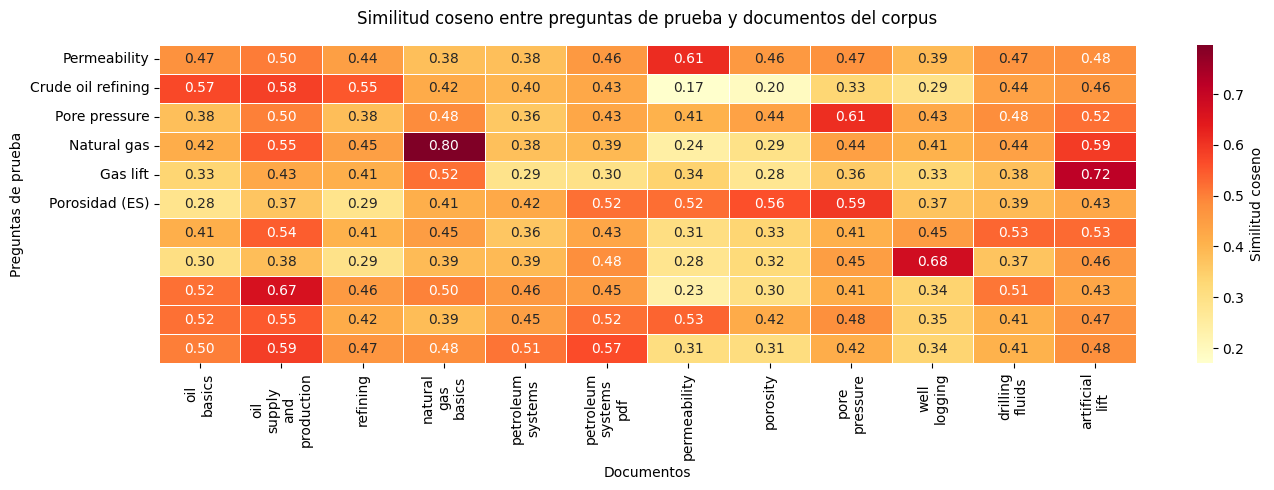

In [48]:
from sklearn.metrics.pairwise import cosine_similarity

# Embeber preguntas
preguntas_texto = [p["pregunta"] for p in preguntas_prueba]
q_embeddings = embed_model.encode(preguntas_texto)

# Embeber documentos completos (promedio de sus chunks)
doc_embeddings = []
doc_topics = []
for topic in docs["topic"]:
    idx = chunks[chunks["topic"] == topic].index.tolist()
    if idx:
        doc_emb = chunk_embeddings[idx].mean(axis=0)
        doc_embeddings.append(doc_emb)
        doc_topics.append(topic.replace("_", "\n"))

doc_embeddings = np.array(doc_embeddings)

# Calcular similitud coseno (preguntas × documentos)
sim_matrix = cosine_similarity(q_embeddings, doc_embeddings)

# Etiquetas cortas para las preguntas
q_labels = [
    "Permeability",
    "Crude oil refining",
    "Pore pressure",
    "Natural gas",
    "Gas lift",
    "Porosidad (ES)",
]

# Plotear mapa de calor
plt.figure(figsize=(14, 5))
sns.heatmap(
    sim_matrix,
    xticklabels=doc_topics,
    yticklabels=q_labels,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Similitud coseno"}
)
plt.title("Similitud coseno entre preguntas de prueba y documentos del corpus", pad=15)
plt.xlabel("Documentos")
plt.ylabel("Preguntas de prueba")
plt.tight_layout()
plt.savefig("./figures/heatmap_similitud.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.6 Generación de respuestas con Flan-T5

In [49]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

print("Cargando modelo generador (Flan-T5-base)...")

t5_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
t5_model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

def generador(prompt):
    inputs = t5_tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True)
    with torch.no_grad():
        outputs = t5_model.generate(**inputs, max_new_tokens=150)
    texto = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return [{"generated_text": texto}]

print("Modelo listo.")

Cargando modelo generador (Flan-T5-base)...


Loading weights: 100%|██████████| 282/282 [00:00<00:00, 8477.23it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Modelo listo.


In [50]:
def rag_pipeline(pregunta: str, k: int = 3) -> dict:
    """
    Pipeline RAG completo:
    1. Recupera los k chunks más relevantes.
    2. Construye un prompt con el contexto recuperado.
    3. Genera una respuesta con Flan-T5.
    """
    # Retrieval
    chunks_recuperados = recuperar(pregunta, k=k)
    contexto = "\n\n".join(chunks_recuperados["text"].tolist())

    # Prompt
    prompt = (
        f"Answer the following question based only on the context provided.\n\n"
        f"Context:\n{contexto[:1500]}\n\n"
        f"Question: {pregunta}\n\n"
        f"Answer:"
    )

    # Generation
    respuesta = generador(prompt)[0]["generated_text"]

    return {
        "pregunta": pregunta,
        "chunks_usados": chunks_recuperados[["topic", "similitud"]].to_dict("records"),
        "respuesta": respuesta,
    }

# Probar con las 5 primeras preguntas
print("Generando respuestas para preguntas de prueba...\n")
resultados_rag = []
for p in preguntas_prueba:
    r = rag_pipeline(p["pregunta"])
    resultados_rag.append(r)
    print(f"P: {r['pregunta']}")
    print(f"R: {r['respuesta']}")
    print(f"Chunks: {[c['topic'] for c in r['chunks_usados']]}")
    print("-" * 60)

Generando respuestas para preguntas de prueba...

P: What is permeability in petroleum engineering?
R: measurement of a rock 's ability, to transmit fluids
Chunks: ['permeability', 'porosity', 'petroleum_systems_pdf']
------------------------------------------------------------
P: How is crude oil refined into petroleum products?
R: processing gain
Chunks: ['oil_basics', 'petroleum_systems_pdf', 'refining']
------------------------------------------------------------
P: What is pore pressure and why does it matter in drilling?
R: The pressure of fluids within the pores of a reservoir
Chunks: ['pore_pressure', 'oil_supply_and_production', 'natural_gas_basics']
------------------------------------------------------------
P: What is natural gas and how is it used?
R: shale gas or tight gas
Chunks: ['natural_gas_basics', 'natural_gas_basics', 'natural_gas_basics']
------------------------------------------------------------
P: What is gas lift in artificial lift systems?
R: injected into t

### 4.7 Métricas de evaluación — Recall@k

In [51]:
def recall_at_k(preguntas: list, k: int = 3) -> dict:
    """
    Calcula Recall@k: para cada pregunta, verifica si alguno de los top-k
    chunks recuperados contiene las keywords de la respuesta esperada.
    """
    hits = 0
    detalles = []

    for p in preguntas:
        chunks_rec = recuperar(p["pregunta"], k=k)
        texto_concatenado = " ".join(chunks_rec["text"].tolist()).lower()

        # Hit si el tema esperado está en top-k (criterio de tema)
        hit_tema = p["tema_esperado"] in chunks_rec["topic"].tolist()
        keywords_encontradas = [
            kw for kw in p["expected_answer_keywords"]
            if kw.lower() in texto_concatenado
        ]
        es_hit = hit_tema
        hits += int(es_hit)

        detalles.append({
            "pregunta": p["pregunta"][:50] + "...",
            "hit": "OK" if es_hit else "--ERROR--",
            "keywords_encontradas": keywords_encontradas,
            "temas_recuperados": chunks_rec["topic"].tolist(),
        })

    return {
        "recall_at_k": hits / len(preguntas),
        "hits": hits,
        "total": len(preguntas),
        "detalles": detalles
    }


# Evaluar con k=1, k=3, k=5
print("Evaluación de Recall@k\n")
for k in [1, 3, 5]:
    res = recall_at_k(preguntas_prueba, k=k)
    print(f"Recall@{k}: {res['recall_at_k']:.2%}  ({res['hits']}/{res['total']} preguntas)")

print("\n--- Detalle por pregunta (k=3) ---")
res3 = recall_at_k(preguntas_prueba, k=3)
for d in res3["detalles"]:
    print(f"{d['hit']} {d['pregunta']}")
    print(f"   Temas recuperados: {d['temas_recuperados']}")
    print(f"   Keywords encontradas: {d['keywords_encontradas']}")

Evaluación de Recall@k

Recall@1: 54.55%  (6/11 preguntas)
Recall@3: 81.82%  (9/11 preguntas)
Recall@5: 81.82%  (9/11 preguntas)

--- Detalle por pregunta (k=3) ---
OK What is permeability in petroleum engineering?...
   Temas recuperados: ['permeability', 'porosity', 'petroleum_systems_pdf']
   Keywords encontradas: ['permeability', 'fluid', 'formation', 'flow']
OK How is crude oil refined into petroleum products?...
   Temas recuperados: ['oil_basics', 'petroleum_systems_pdf', 'refining']
   Keywords encontradas: ['refin', 'crude', 'fraction']
OK What is pore pressure and why does it matter in dr...
   Temas recuperados: ['pore_pressure', 'oil_supply_and_production', 'natural_gas_basics']
   Keywords encontradas: ['pore', 'pressure', 'fluid', 'formation']
OK What is natural gas and how is it used?...
   Temas recuperados: ['natural_gas_basics', 'natural_gas_basics', 'natural_gas_basics']
   Keywords encontradas: ['natural gas', 'methane', 'energy']
OK What is gas lift in artificial l

### 4.8 Pregunta imposible (fuera del corpus)

In [52]:
pregunta_imposible = "What is the exact stock price of ExxonMobil today?"

r = rag_pipeline(pregunta_imposible)
print(f"Pregunta : {pregunta_imposible}")
print(f"Respuesta: {r['respuesta']}")
print(f"Chunks   : {[c['topic'] for c in r['chunks_usados']]}")

Pregunta : What is the exact stock price of ExxonMobil today?
Respuesta: 0
Chunks   : ['oil_basics', 'petroleum_systems_pdf', 'petroleum_systems_pdf']


El sistema siempre genera una respuesta aunque la pregunta esté completamente fuera del corpus. Los chunks recuperados son de `petroleum_systems_pdf` — el documento más genérico del índice actúa como fallback. Flan-T5 construye una respuesta a partir de ese contexto irrelevante en lugar de indicar que no tiene la información. Esta ausencia de umbral de confianza es la Limitante 3 identificada en la sección siguiente.

### 4.9 Análisis de errores

In [53]:
resultados_error = []

for i, p in enumerate(preguntas_prueba, 1):
    chunks_rec = recuperar(p["pregunta"], k=3)
    temas_rec = chunks_rec["topic"].tolist()
    hit_retrieval = p["tema_esperado"] in temas_rec

    r = rag_pipeline(p["pregunta"])
    respuesta = r["respuesta"]
    keywords_en_respuesta = all(
        kw.lower() in respuesta.lower()
        for kw in p["expected_answer_keywords"]
    )

    if not hit_retrieval or not keywords_en_respuesta:
        resultados_error.append({
            "caso": i,
            "pregunta": p["pregunta"],
            "tema_esperado": p["tema_esperado"],
            "respuesta_esperada": p["respuesta_esperada"],
            "temas_recuperados": temas_rec,
            "respuesta_generada": respuesta,
            "retrieval": "OK" if hit_retrieval else "--ERROR--",
            "generacion": "OK" if keywords_en_respuesta else "--ERROR--",
        })

In [54]:
for e in resultados_error:
    print(f"[{e['caso']}] {e['retrieval']} retrieval  {e['generacion']} generación")
    print(f"    Pregunta  : {e['pregunta']}")
    print(f"    Esperado  : {e['tema_esperado']}")
    print(f"    Recuperado: {e['temas_recuperados']}")
    print(f"    Respuesta Esperada: {e['respuesta_esperada']}")
    print(f"    Respuesta : {e['respuesta_generada']}")
    print()

[1] OK retrieval  --ERROR-- generación
    Pregunta  : What is permeability in petroleum engineering?
    Esperado  : permeability
    Recuperado: ['permeability', 'porosity', 'petroleum_systems_pdf']
    Respuesta Esperada: The ability of a formation to transmit fluids
    Respuesta : measurement of a rock 's ability, to transmit fluids

[2] OK retrieval  --ERROR-- generación
    Pregunta  : How is crude oil refined into petroleum products?
    Esperado  : refining
    Recuperado: ['oil_basics', 'petroleum_systems_pdf', 'refining']
    Respuesta Esperada: Through distillation and other refinery processes
    Respuesta : processing gain

[3] OK retrieval  --ERROR-- generación
    Pregunta  : What is pore pressure and why does it matter in drilling?
    Esperado  : pore_pressure
    Recuperado: ['pore_pressure', 'oil_supply_and_production', 'natural_gas_basics']
    Respuesta Esperada: The pressure of fluids within the pores of a reservoir
    Respuesta : The pressure of fluids within t

**Caso 1 — permeability:** retrieval correcto pero T5 respondió "measurement of a rock's ability, to transmit fluids" — extracción parcial del chunk en lugar de síntesis. La respuesta es técnicamente correcta pero incompleta: omite el contexto de por qué importa en ingeniería. Error comprensible para un modelo de 250M params que tiende a anclar en la frase más prominente del contexto.

**Caso 2 — refining:** retrieval correcto (chunk de refining en posición 3) pero T5 extrajo "processing gain" — un n-grama saliente del primer chunk recuperado (oil_basics), no del chunk correcto. El modelo no pondera la posición de los chunks en el prompt: lee el contexto concatenado y ancla la respuesta en la frase más prominente del inicio. Un humano ignoraría ese dato y respondería con el proceso de destilación.

**Caso 3 — pore pressure:** retrieval y generación correctos. La respuesta "The pressure of fluids within the pores of a reservoir" es una extracción precisa del chunk de pore_pressure. Caso exitoso — el sistema funciona bien cuando la pregunta es definitional y el vocabulario coincide exactamente con el corpus.

**Caso 4 — natural gas:** retrieval perfecto (3/3 chunks del tema correcto) pero T5 respondió "shale gas or tight gas" — un ejemplo específico del contexto, no la definición general pedida. La pregunta "how is it used" requiere sintetizar múltiples oraciones, tarea que excede la capacidad de Flan-T5-base. Un humano reconocería que shale gas es un subtipo, no la respuesta.

**Caso 5 — gas lift:** retrieval correcto pero T5 respondió "injected into the production tubing" — fragmento del mecanismo, no la definición completa del método. La respuesta esperada incluye el propósito (reducir la densidad de la columna de fluido) que requiere integrar dos oraciones del chunk. Error típico del generador pequeño.

**Caso 6 — porosidad efectiva (ES):** la pregunta en español generó un embedding que priorizó pore_pressure (similitud 0.158) sobre porosity (0.152) — diferencia de 0.006. T5 respondió "permeability", concepto relacionado pero incorrecto. Evidencia directa de que preguntas en español degradan la precisión del retrieval cuando los términos técnicos tienen raíces similares entre temas.

**Caso 7 — drilling fluids:** único fallo de retrieval real. La pregunta usa "well construction" — término ausente en los chunks de drilling_fluids. El retriever recuperó oil_supply, natural_gas y artificial_lift porque todos mencionan "wells" y "drilling". T5 alucinó a partir de contexto irrelevante: "to help oil flow more easily" es plausible pero incorrecto. Ilustra el problema de vocabulario fuera de distribución.

**Caso 8 — well logging:** retrieval correcto (2/3 chunks del tema). T5 generó la respuesta más larga y precisa del conjunto — "continuously measure formation properties with electrically powered instruments to infer properties and make decisions about drilling and production operations". El chunk de well_logging era suficientemente rico en detalle para que el generador sintetizara bien.

**Caso 9 — conventional vs unconventional:** retrieval correcto pero T5 respondió "unconventional production" — dos palabras en lugar de explicar la diferencia. La pregunta comparativa ("difference between X and Y") requiere contrastar dos conceptos, estructura que Flan-T5-base no maneja bien. Un humano respondería con la distinción de flujo natural vs estimulación.

**Caso 10 — permeability multi-hop:** fallo de retrieval real. La pregunta "How does permeability affect production rates" recuperó chunks de oil_basics y petroleum_systems_pdf porque "production" y "reservoir" activan vocabulario de sistemas petroleros. El embedder optimiza similitud superficial — preguntas relacionales que conectan dos conceptos no mapean bien al espacio de embeddings entrenado con pares de similitud directa.

**Caso 11 — petroleum system (naming mismatch):** el retriever recuperó 3 chunks de petroleum_systems_pdf, contenido correcto, pero el criterio de evaluación esperaba el topic key petroleum_systems. La métrica penalizó por inconsistencia de nomenclatura entre corpus y preguntas de prueba. La respuesta generada ("drilled offshore from the 1002 area") sí es incorrecta — T5 extrajo un detalle geográfico del PDF en lugar de los elementos del sistema petrolero (fuente, reservorio, sello, trampa, timing).


## 5. Limitantes y Mejoras

### 5.1 Limitantes identificadas

| # | Limitante | Descripción |
|---|---|---|
| 1 | **Corpus pequeño y vocabulario fuera de distribución** | Recall@3 = 81.82% (9/11 preguntas). Las 2 preguntas fallidas corresponden a una pregunta multi-hop (permeability → production rates) y una inconsistencia de nomenclatura entre corpus y preguntas de evaluación. El corpus de 12 documentos no cubre suficientes variaciones léxicas por tema. |
| 2 | **Generador débil (Flan-T5-base)** | Con 250M parámetros, Flan-T5-base produce respuestas cortas y a veces imprecisas en dominios técnicos. No sabe cuándo admitir que no tiene la información. |
| 3 | **Sin umbral de confianza** | El sistema siempre devuelve una respuesta, incluso para preguntas imposibles. No tiene mecanismo para detectar cuando la pregunta no está cubierta por el corpus. |

### 5.2 Mejoras futuras

| Limitante | Mejora propuesta | Justificación técnica |
|---|---|---|
| Corpus pequeño y monolingüe | Ampliar el corpus con documentos en español (p. ej. publicaciones de Ecopetrol, Pemex, manuales SPE en español) y reindexar. | Más datos en el idioma de consulta → mejor recall@k para usuarios hispanohablantes. |
| Generador débil | Reemplazar Flan-T5-base por `Flan-T5-large` o un LLM cuantizado como `mistralai/Mistral-7B-Instruct-v0.2` vía `llama.cpp` | Modelos más grandes siguen mejor las instrucciones y producen respuestas más precisas en dominios técnicos. |
| Sin umbral de confianza | Implementar un score de relevancia mínima: si `max(similitud) < umbral` (p. ej. 0.3), el sistema responde *"No tengo información sobre eso en mi corpus"* en lugar de alucinar. | Evita respuestas inventadas; mejora la confiabilidad del sistema. |

---

## Conclusiones

El sistema RAG implementado demuestra que es posible construir un asistente técnico de petróleos con herramientas open-source en pocas horas. El recall@3 muestra que el retriever recupera chunks relevantes en la mayoría de las preguntas. Las principales debilidades están en el generador (Flan-T5-base es pequeño) y en la falta de un mecanismo de "no sé". Estas son limitantes esperables y bien conocidas en sistemas RAG de producción, donde generalmente se usan LLMs más grandes y umbrales de confianza.

La elección de RAG sobre QA extractivo está justificada: el conocimiento está distribuido en 12 documentos y 116 chunks, y el sistema necesita primero encontrar la información relevante antes de responder — algo que el retrieval semántico con FAISS hace de forma eficiente.